# Test NetCDF for Telemetered PLIMS Data

Using sample NetCDFs from stream engine for the new telemetered streams of moored PLIMS data, opening data files, accessing data and checking metadata validity.

### Extract datasets from zipped sample streams

The following cells use Windows cell magic to extract files from tarballs. Commands will likely need to be changed in order to run these cells on another OS.

In [ ]:
%%cmd
cd C:/Users/kylene.cooley/PLIMS/
mkdir test_streams_2025_02_24


Microsoft Windows [Version 10.0.19045.5371]
(c) Microsoft Corporation. All rights reserved.

(ooi) c:\Users\kylene.cooley\Documents\GitHub\pioneer-20>cd C:/Users/kylene.cooley/PLIMS/

(ooi) C:\Users\kylene.cooley\PLIMS>mkdir test_streams_2025_02_24

(ooi) C:\Users\kylene.cooley\PLIMS>cd ./test_streams_2025_02_24

(ooi) C:\Users\kylene.cooley\PLIMS\test_streams_2025_02_24>tar -xzf C:/Users/kylene.cooley/Downloads/hdr_instrument.tar.gz 

(ooi) C:\Users\kylene.cooley\PLIMS\test_streams_2025_02_24>

In [ ]:
%%cmd
cd C:/Users/kylene.cooley/PLIMS/test_streams_2025_02_24
tar -xzf C:/Users/kylene.cooley/Downloads/hdr_instrument.tar.gz 
tar -xzf C:/Users/kylene.cooley/Downloads/adc_instrument.tar.gz 
tar -xzf C:/Users/kylene.cooley/Downloads/hdr_engineering.tar.gz 

Microsoft Windows [Version 10.0.19045.5371]
(c) Microsoft Corporation. All rights reserved.

(ooi) c:\Users\kylene.cooley\Documents\GitHub\pioneer-20>cd C:/Users/kylene.cooley/PLIMS/test_streams_2025_02_24

(ooi) C:\Users\kylene.cooley\PLIMS\test_streams_2025_02_24># tar -xzf C:/Users/kylene.cooley/Downloads/hdr_instrument.tar.gz 


'#' is not recognized as an internal or external command,
operable program or batch file.



(ooi) C:\Users\kylene.cooley\PLIMS\test_streams_2025_02_24>tar -xzf C:/Users/kylene.cooley/Downloads/adc_instrument.tar.gz 

(ooi) C:\Users\kylene.cooley\PLIMS\test_streams_2025_02_24>tar -xzf C:/Users/kylene.cooley/Downloads/hdr_engineering.tar.gz 

(ooi) C:\Users\kylene.cooley\PLIMS\test_streams_2025_02_24>

In [11]:
%%cmd
cd

Microsoft Windows [Version 10.0.19045.5371]
(c) Microsoft Corporation. All rights reserved.

(ooi) c:\Users\kylene.cooley\Documents\GitHub\pioneer-20>cd
c:\Users\kylene.cooley\Documents\GitHub\pioneer-20

(ooi) c:\Users\kylene.cooley\Documents\GitHub\pioneer-20>

### Import Python packages

In [5]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


## plims_a_hdr_instrument Science Stream

### Import datasets included in HDR science stream folder

In [2]:
# Load the HDR file dataset
path = "C:/Users/kylene.cooley/PLIMS/test_streams_2025_02_24/20250220T191955527Z-CP10CNSM-RID27-07-PLIMSA000-recovered-plims_a_hdr_instrument/deployment0001_CP10CNSM-RID27-07-PLIMSA000-recovered-plims_a_hdr_instrument_20240601T002503-20241031T202438.nc"
ds_hdr = xr.load_dataset(path, engine="netcdf4")
ds_hdr = ds_hdr.swap_dims({"obs": "time"})
ds_hdr

C:\Users\kylene.cooley\AppData\Local\Temp\ipykernel_28504\1558435694.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_hdr = xr.load_dataset(path, engine="netcdf4")


<xarray.Dataset> Size: 156kB
Dimensions:              (time: 535)
Coordinates:
    obs                  (time) int32 2kB 0 1 2 3 4 5 ... 530 531 532 533 534
  * time                 (time) datetime64[ns] 4kB 2024-06-01T00:25:03 ... 20...
Data variables: (12/34)
    pmta_threshold       (time) float32 2kB 0.135 0.135 0.135 ... 0.135 0.135
    rois_per_ml          (time) float64 4kB 254.0 200.7 332.5 ... 96.1 92.93
    pmtb_threshold       (time) float32 2kB 0.13 0.13 0.13 ... 0.13 0.13 0.13
    sample_speed         (time) timedelta64[ns] 4kB 00:20:00 ... 00:20:00
    beads_counter        (time) float64 4kB 10.0 11.0 13.0 ... 13.0 14.0 15.0
    run_fast_factor      (time) float64 4kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    ...                   ...
    volume_analyzed      (time) float64 4kB 4.59 4.674 3.967 ... 4.839 4.842
    blob_gap_min         (time) float64 4kB 50.0 50.0 50.0 ... 50.0 50.0 50.0
    blob_area_min        (time) float64 4kB 2e+03 2e+03 2e+03 ... 2e+03 2e+03
    blob_x_grow          (time) float64 4kB 20.0 20.0 20.0 ... 20.0 20.0 20.0
    look_time            (time) float32 2kB 1.102e+03 1.122e+03 ... 1.162e+03
    sample_num           (time) float64 4kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
Attributes: (12/70)
    node:                               RID27
    comment:                            
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered
    stream:                             plims_a_hdr_instrument
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    lat:                                35.94988
    lon:                                -75.11943

### Create plots of HDR dataset parameters

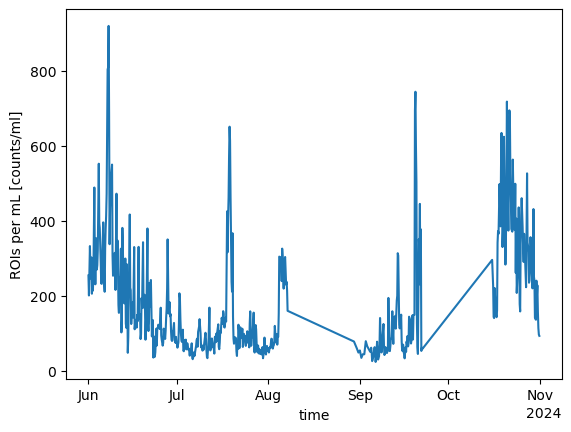

In [72]:
ds_hdr.rois_per_ml.plot()

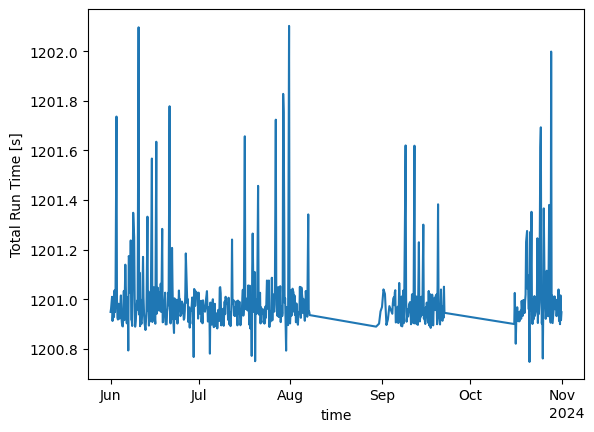

In [75]:
ds_hdr.run_time.plot()

## plims_a_adc_instrument Science Stream

In [3]:
# Load the ADC file dataset
path = "C:/Users/kylene.cooley/PLIMS/test_streams_2025_02_24/20250220T191910574Z-CP10CNSM-RID27-07-PLIMSA000-recovered-plims_a_adc_instrument/deployment0001_CP10CNSM-RID27-07-PLIMSA000-recovered-plims_a_adc_instrument_20240601T002514.362513-20241031T204438.910647.nc"
ds_adc = xr.load_dataset(path)
ds_adc = ds_adc.swap_dims({"obs": "time"})
ds_adc

<xarray.Dataset> Size: 153MB
Dimensions:              (time: 518348)
Coordinates:
    obs                  (time) int32 2MB 0 1 2 3 ... 518345 518346 518347
  * time                 (time) datetime64[ns] 4MB 2024-06-01T00:25:14.362512...
Data variables: (12/27)
    driver_timestamp     (time) datetime64[ns] 4MB 2025-02-20T15:00:07.973861...
    id                   (time) |S36 19MB b'bae0825e-3577-4b12-8c25-24998b830...
    inhibit_time_tr      (time) float32 2MB 0.0934 0.1775 0.2614 ... 38.78 38.79
    peak_b               (time) |S32 17MB b'0.24531841' ... b'0.0038313865999...
    peak_a               (time) |S32 17MB b'0.035264492' ... b'0.008311272'
    grab_time_start      (time) float32 2MB 11.36 13.66 ... 1.201e+03 1.201e+03
    ...                   ...
    port_timestamp       (time) datetime64[ns] 4MB 1900-01-01 ... 1900-01-01
    inhibit_time         (time) float64 4MB 99.32 99.32 99.32 ... 38.79 38.79
    run_time             (time) float64 4MB 1.201e+03 1.201e+03 ... 1.201e+03
    deployment           (time) int32 2MB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    preferred_timestamp  (time) object 4MB b'internal_timestamp' ... b'intern...
    look_time            (time) float64 4MB 1.102e+03 1.102e+03 ... 1.162e+03
Attributes: (12/70)
    node:                               RID27
    comment:                            
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered
    stream:                             plims_a_adc_instrument
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    lat:                                35.94988
    lon:                                -75.11943

Text(0.5, 0.98, 'Interpolated times from HDR file in adc_instrument stream')

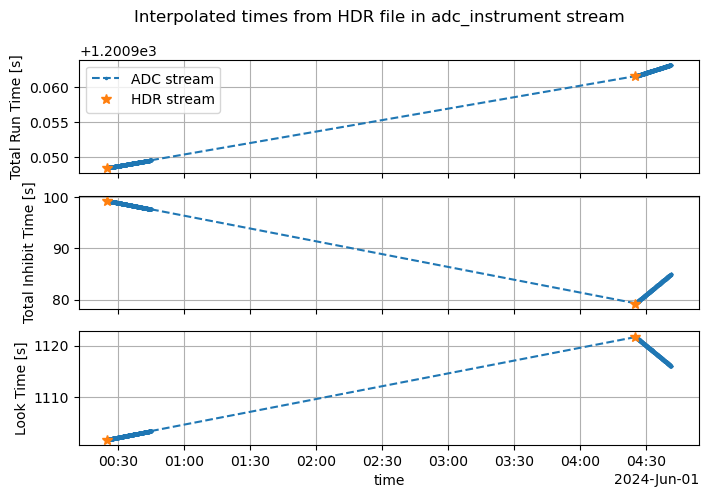

In [87]:
fig, axs = plt.subplots(3, 1, figsize=(8,5), sharex=True)
ds_adc.look_time[0:2000].plot(marker='.', markersize=3, linestyle='--', ax=axs[2])
ds_hdr.look_time[0:2].plot(ax=axs[2], marker='*', markersize=7, linestyle='none')
axs[2].grid()
ds_adc.run_time[0:2000].plot(marker='.', markersize=3, linestyle='--', ax=axs[0], label="ADC stream")
ds_hdr.run_time[0:2].plot(ax=axs[0], marker='*', markersize=7, linestyle='none', label="HDR stream")
axs[0].legend()
axs[0].set_xlabel("")
axs[0].grid()
ds_adc.inhibit_time[0:2000].plot(marker='.', markersize=3, linestyle='--', ax=axs[1])
ds_hdr.inhibit_time[0:2].plot(ax=axs[1], marker='*', markersize=7, linestyle='none')
axs[1].set_xlabel("")
axs[1].grid()
plt.suptitle("Interpolated times from HDR file in adc_instrument stream")

In [46]:
da_time_of_flight = ds_adc.time_of_flight.where(ds_adc.time_of_flight<10000)

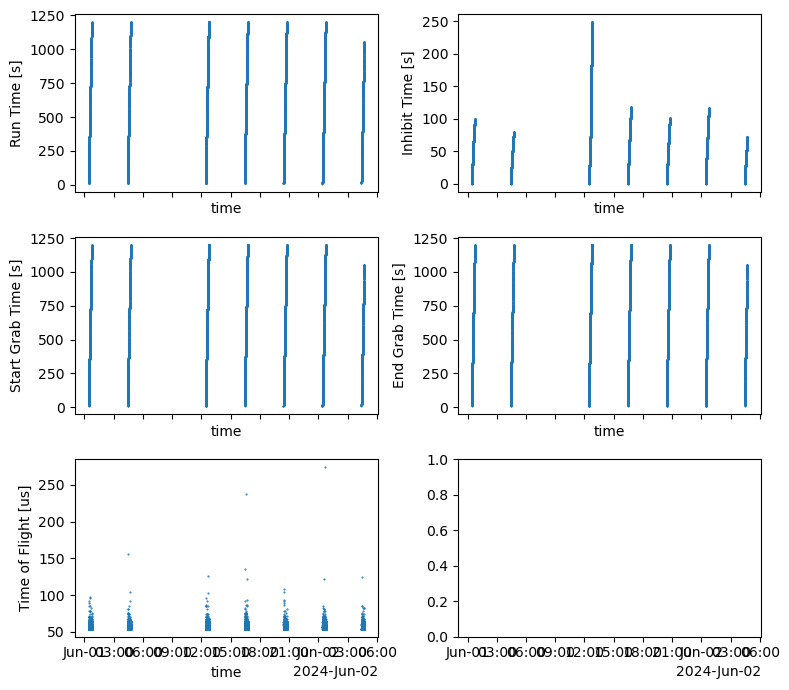

In [63]:
fig, axs = plt.subplots(3, 2, figsize=[8, 7], layout="tight", sharex=True)
ds_adc.run_time_tr[0:10000].plot(ax=axs[0][0], linestyle='none', marker='.', markersize=1)
ds_adc.inhibit_time_tr[0:10000].plot(ax=axs[0][1], linestyle='none', marker='.', markersize=1)
ds_adc.grab_time_start[0:10000].plot(ax=axs[1][0], linestyle='none', marker='.', markersize=1)
ds_adc.grab_time_end[0:10000].plot(ax=axs[1][1], linestyle='none', marker='.', markersize=1)
da_time_of_flight[0:10000].plot(ax=axs[2][0], linestyle='none', marker='.', markersize=1)

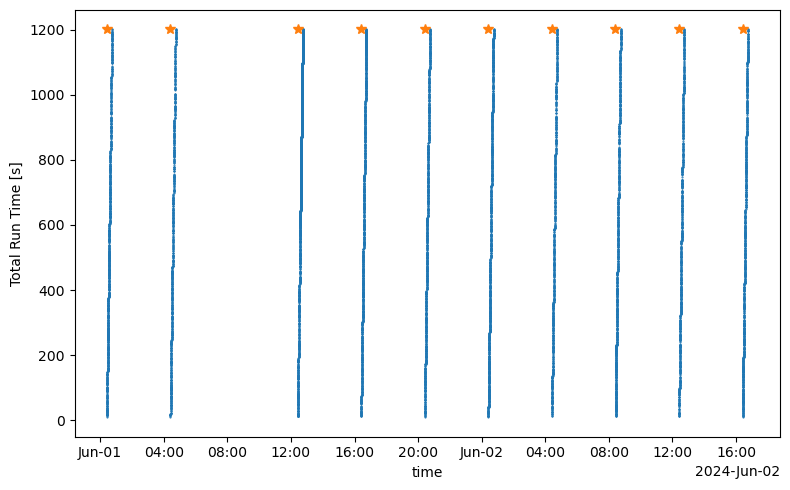

In [94]:
fig, axs = plt.subplots(figsize=[8, 5], layout="tight")
ds_adc.run_time_tr.sel(time=slice("2024-06-02")).plot(ax=axs, linestyle='none', marker='.', markersize=1)
ds_hdr.run_time.sel(time=slice("2024-06-02")).plot(ax=axs, linestyle='none', marker='*', markersize=7)

In [3]:
ds_adc.peak_a.astype('float')

<xarray.DataArray 'peak_a' (time: 518348)> Size: 4MB
array([0.03526449, 0.41809797, 0.03512144, ..., 3.4948063 , 0.00831127,
       0.00831127])
Coordinates:
    obs      (time) int32 2MB 0 1 2 3 4 5 ... 518343 518344 518345 518346 518347
  * time     (time) datetime64[ns] 4MB 2024-06-01T00:25:14.362512896 ... 2024...
Attributes:
    name:     peak_a

## plims_a_hdr_engineering Engineering Data Stream

In [2]:
# Load the HDR file dataset
path = "C:/Users/kylene.cooley/PLIMS/test_streams_2025_02_24/20250220T191850158Z-CP10CNSM-RID27-07-PLIMSA000-recovered-plims_a_hdr_engineering/deployment0001_CP10CNSM-RID27-07-PLIMSA000-recovered-plims_a_hdr_engineering_20240601T002503-20241031T202438.nc"
ds_hdr_eng = xr.load_dataset(path, engine="netcdf4")
ds_hdr_eng = ds_hdr_eng.swap_dims({"obs": "time"})
ds_hdr_eng

<xarray.Dataset> Size: 188kB
Dimensions:               (time: 535)
Coordinates:
    obs                   (time) int32 2kB 0 1 2 3 4 5 ... 530 531 532 533 534
  * time                  (time) datetime64[ns] 4kB 2024-06-01T00:25:03 ... 2...
Data variables: (12/51)
    provenance            (time) |S36 19kB b'f8ea7b24-4a86-487e-895f-f78a3ca0...
    pump1_state           (time) float32 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    refill_debubble       (time) float32 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    prime_sample          (time) float32 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    deployment            (time) int32 2kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    alt_interval          (time) float64 4kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    ...                    ...
    focus_motor_step_lg   (time) float64 4kB 300.0 300.0 300.0 ... 300.0 300.0
    syringes_autorun      (time) float64 4kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    bleach_rinse_ct       (time) float64 4kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    auto_start            (time) float32 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    sample_volume_skip    (time) float32 2kB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    beads_int             (time) float64 4kB 40.0 40.0 40.0 ... 40.0 40.0 40.0
Attributes: (12/70)
    node:                               RID27
    comment:                            
    publisher_email:                    
    sourceUrl:                          http://oceanobservatories.org/
    collection_method:                  recovered
    stream:                             plims_a_hdr_engineering
    ...                                 ...
    geospatial_lon_resolution:          0.1
    geospatial_vertical_units:          meters
    geospatial_vertical_resolution:     0.1
    geospatial_vertical_positive:       down
    lat:                                35.94988
    lon:                                -75.11943

In [15]:
t_sample = pd.to_datetime(ds_hdr_eng.sample_timestamp, unit='s', origin="1900-01-01")

In [16]:
t_sample - ds_hdr_eng.internal_timestamp.values

TimedeltaIndex(['0 days 00:02:41', '0 days 00:01:37', '0 days 00:03:26',
                '0 days 00:02:39', '0 days 00:01:36', '0 days 00:00:33',
                '0 days 00:03:45', '0 days 00:02:40', '0 days 00:01:35',
                '0 days 00:00:32',
                ...
                '0 days 00:04:07', '0 days 00:03:06', '0 days 00:00:57',
                '0 days 00:04:07', '0 days 00:03:03', '0 days 00:01:59',
                '0 days 00:00:55', '0 days 00:04:08', '0 days 00:03:05',
                '0 days 00:02:02'],
               dtype='timedelta64[ns]', length=535, freq=None)